# 01 - Constant current, dQ/dV, power, energy density, and simple fade

Goal: run a DFN cell at a chosen C-rate, inspect the voltage profile,
calculate an incremental-capacity curve, try a CC-CV charge, and connect
the result to power and energy density.

PyBaMM pieces used here:

- `pybamm.lithium_ion.DFN`
- `pybamm.Experiment`
- `pybamm.Simulation`
- `sim.plot(...)` and `pybamm.QuickPlot`

Docs:

- DFN example: https://docs.pybamm.org/en/stable/source/examples/notebooks/models/DFN.html
- Simulation API: https://docs.pybamm.org/en/stable/source/api/simulation.html
- Experiment API: https://docs.pybamm.org/en/stable/source/api/experiment/experiment.html
- Plotting API: https://docs.pybamm.org/en/stable/source/api/plotting/index.html

In [1]:
import os

os.environ.setdefault("PYBAMM_DISABLE_TELEMETRY", "true")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pybamm

print("PyBaMM version:", pybamm.__version__)

PyBaMM version: 26.6.2.0


In [2]:
model = pybamm.lithium_ion.DFN()
parameter_values = model.default_parameter_values

q_nom = parameter_values["Nominal cell capacity [A.h]"]
v_min = parameter_values["Lower voltage cut-off [V]"]
v_max = parameter_values["Upper voltage cut-off [V]"]
cell_volume_l = parameter_values["Cell volume [m3]"] * 1000

print(f"Nominal capacity: {q_nom:.4g} A.h")
print(f"Voltage window:   {v_min:.3f} V to {v_max:.3f} V")
print(f"Cell volume:      {cell_volume_l:.4g} L")

Nominal capacity: 0.6806 A.h
Voltage window:   3.105 V to 4.100 V
Cell volume:      0.0078 L


## Important formulas

At a C-rate of `C_rate`, PyBaMM interprets the current scale using the
nominal cell capacity:

$$
I = C_{rate} Q_{nom}
$$

Capacity is the time-integral of current:

$$
Q(t) = \frac{1}{3600}\int_0^t I(t')\,dt'
$$

For a discharge curve, voltage decreases while discharge capacity increases.
We plot `-dQ/dV` so peaks are positive:

$$
-\frac{dQ}{dV}
$$

Power and energy:

$$
P(t) = I(t)V(t), \qquad
E(t) = \frac{1}{3600}\int_0^t P(t')\,dt'
$$

Volumetric values use the PyBaMM default cell volume:

$$
P_V = \frac{P}{V_{cell}}, \qquad E_V = \frac{E}{V_{cell}}
$$

In [3]:
def solve_constant_current(c_rate=1.0, period="30 seconds", initial_soc=1.0):
    model = pybamm.lithium_ion.DFN()
    parameter_values = model.default_parameter_values
    v_min = parameter_values["Lower voltage cut-off [V]"]

    experiment = pybamm.Experiment(
        [f"Discharge at {c_rate}C until {v_min} V"],
        period=period,
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=parameter_values,
        experiment=experiment,
        output_variables=[
            "Voltage [V]",
            "Current [A]",
            "Discharge capacity [A.h]",
            "Power [W]",
        ],
    )
    solution = sim.solve(initial_soc=initial_soc)
    return sim, solution


c_rate = 1.0
sim, solution = solve_constant_current(c_rate=c_rate)

print("Termination:", solution.termination)
print(f"Final time: {solution['Time [h]'].entries[-1]:.3f} h")
print(f"Delivered capacity: {solution['Discharge capacity [A.h]'].entries[-1]:.3f} A.h")

Termination: event: Voltage < 3.105 [V] [experiment]
Final time: 1.255 h
Delivered capacity: 0.854 A.h


## PyBaMM quick plot

Remember the parentheses: `sim.plot` points to the method, while
`sim.plot()` runs it.

In [ ]:
sim.plot(
    output_variables=[
        "Voltage [V]",
        "Current [A]",
        "Discharge capacity [A.h]",
        "Power [W]",
    ]
)

interactive(children=(FloatSlider(value=0.0, description='t', max=1.254960147086282, step=0.01254960147086282)…

## Voltage profile and dQ/dV

dQ/dV highlights where a small voltage change corresponds to a large
capacity change. In real cells this is often used to identify phase changes,
electrode balance shifts, and ageing signatures. Here it is a clean
model-based demonstration.

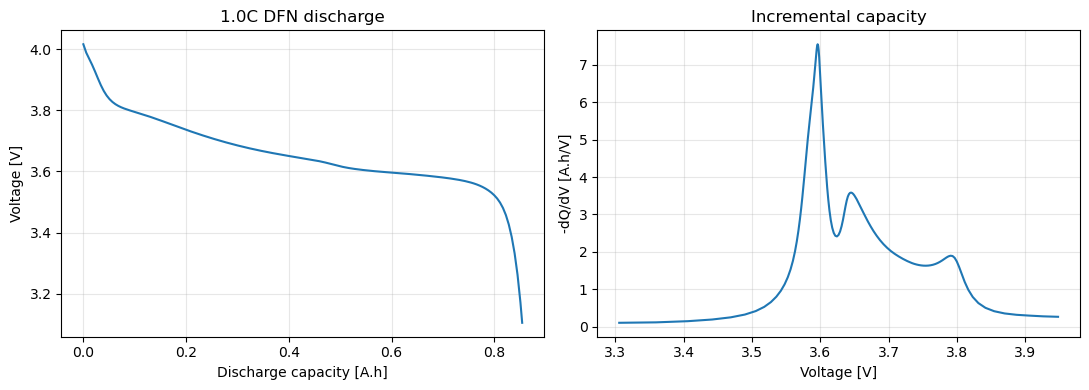

In [9]:
voltage = solution["Voltage [V]"].entries
capacity = solution["Discharge capacity [A.h]"].entries

def moving_average(x, window=7):
    if window <= 1:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

window = 7
voltage_s = moving_average(voltage, window)
capacity_s = moving_average(capacity, window)
minus_dq_dv = -np.gradient(capacity_s, voltage_s)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(capacity, voltage)
axes[0].set_xlabel("Discharge capacity [A.h]")
axes[0].set_ylabel("Voltage [V]")
axes[0].set_title(f"{c_rate}C DFN discharge")
axes[0].grid(True, alpha=0.3)

axes[1].plot(voltage_s, minus_dq_dv)
axes[1].set_xlabel("Voltage [V]")
axes[1].set_ylabel("-dQ/dV [A.h/V]")
axes[1].set_title("Incremental capacity")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Power and energy density

PyBaMM's default DFN parameter set has `Cell volume [m3]`, so the default
density plots are volumetric. If you know your cell mass, set `cell_mass_kg`
to also calculate gravimetric values.

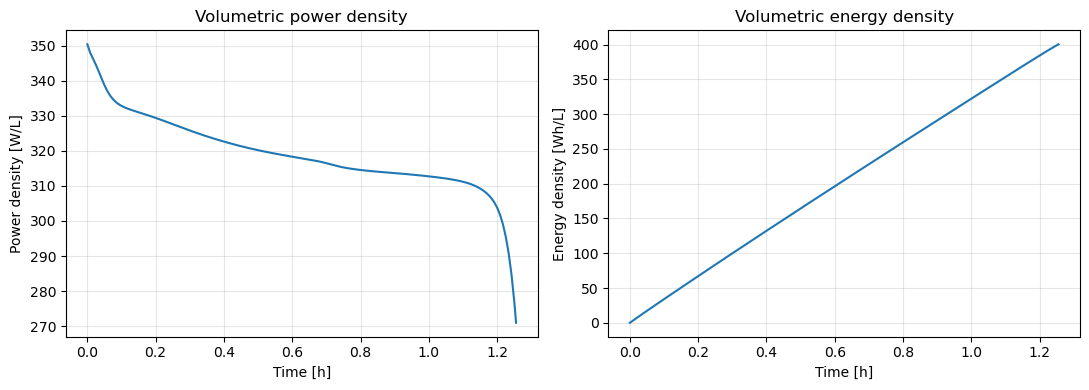

Peak power density:  350.4 W/L
Final energy density: 400.5 Wh/L


In [10]:
time_s = solution["Time [s]"].entries
power_w = solution["Power [W]"].entries

energy_wh = np.zeros_like(power_w)
energy_wh[1:] = np.cumsum(
    0.5 * (power_w[1:] + power_w[:-1]) * np.diff(time_s) / 3600
)

cell_volume_l = parameter_values["Cell volume [m3]"] * 1000
power_density_w_l = power_w / cell_volume_l
energy_density_wh_l = energy_wh / cell_volume_l

cell_mass_kg = None  # Example: set to 0.045 for a 45 g cell.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(solution["Time [h]"].entries, power_density_w_l)
axes[0].set_xlabel("Time [h]")
axes[0].set_ylabel("Power density [W/L]")
axes[0].set_title("Volumetric power density")
axes[0].grid(True, alpha=0.3)

axes[1].plot(solution["Time [h]"].entries, energy_density_wh_l)
axes[1].set_xlabel("Time [h]")
axes[1].set_ylabel("Energy density [Wh/L]")
axes[1].set_title("Volumetric energy density")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"Peak power density:  {np.nanmax(power_density_w_l):.1f} W/L")
print(f"Final energy density: {energy_density_wh_l[-1]:.1f} Wh/L")

if cell_mass_kg is not None:
    print(f"Peak specific power:  {np.nanmax(power_w / cell_mass_kg):.1f} W/kg")
    print(f"Final specific energy: {energy_wh[-1] / cell_mass_kg:.1f} Wh/kg")

## Constant-voltage hold after constant-current charge

In battery cycling, "CC-CV" means a constant-current charge until the upper
voltage limit, followed by a constant-voltage hold while the current tapers.
PyBaMM supports this directly with experiment strings.

A common stopping rule is:

$$
|I| \leq \frac{Q_{nom}}{20\ \mathrm{h}}
$$

which is written as `C/20` in the experiment.

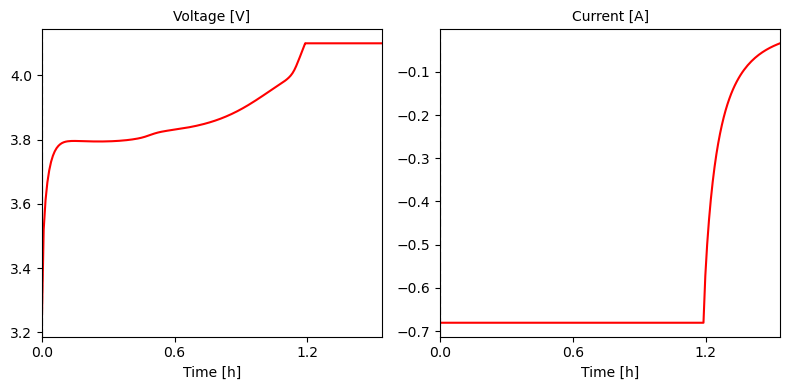

In [11]:
cccv_experiment = pybamm.Experiment(
    [(f"Charge at 1C until {v_max} V", f"Hold at {v_max} V until C/20")],
    period="30 seconds",
)

cccv_sim = pybamm.Simulation(
    pybamm.lithium_ion.DFN(),
    parameter_values=parameter_values,
    experiment=cccv_experiment,
    output_variables=["Voltage [V]", "Current [A]"],
)
cccv_solution = cccv_sim.solve(initial_soc=0)

pybamm.QuickPlot(cccv_solution, ["Voltage [V]", "Current [A]"]).plot(0)

## Optional: a small capacity-fade demo

This adds a simple SEI degradation option. The example is intentionally
short so it runs quickly in class. Increase `n_cycles` if you want a more
visible trend.

PyBaMM degradation examples:
https://docs.pybamm.org/en/stable/source/examples/notebooks/models/coupled-degradation.html

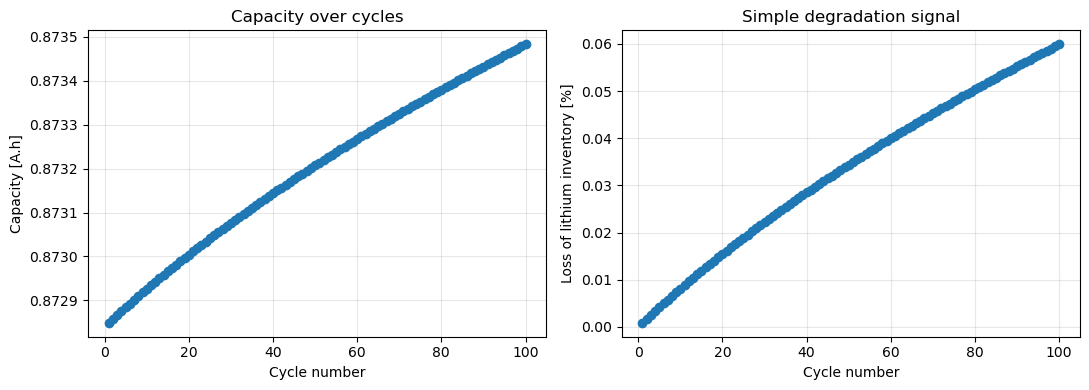

In [14]:
n_cycles = 100

fade_model = pybamm.lithium_ion.DFN({"SEI": "solvent-diffusion limited"})
fade_params = fade_model.default_parameter_values
v_min = fade_params["Lower voltage cut-off [V]"]
v_max = fade_params["Upper voltage cut-off [V]"]

fade_cycle = (
    f"Discharge at 1C until {v_min} V",
    f"Charge at 1C until {v_max} V",
    f"Hold at {v_max} V until C/20",
)

fade_experiment = pybamm.Experiment([fade_cycle] * n_cycles, period="5 minutes")
fade_sim = pybamm.Simulation(
    fade_model,
    parameter_values=fade_params,
    experiment=fade_experiment,
)
fade_solution = fade_sim.solve(initial_soc=1)

cycle_number = np.arange(1, len(fade_solution.cycles) + 1)
capacity_ah = np.asarray(fade_solution.summary_variables["Capacity [A.h]"], dtype=float)
lli_percent = np.asarray(
    fade_solution.summary_variables["Loss of lithium inventory [%]"], dtype=float
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(cycle_number, capacity_ah, "o-")
axes[0].set_xlabel("Cycle number")
axes[0].set_ylabel("Capacity [A.h]")
axes[0].set_title("Capacity over cycles")
axes[0].grid(True, alpha=0.3)

axes[1].plot(cycle_number, lli_percent, "o-")
axes[1].set_xlabel("Cycle number")
axes[1].set_ylabel("Loss of lithium inventory [%]")
axes[1].set_title("Simple degradation signal")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()